Hybrid modelling with the SIRS model
---
In this notebook we experiment with various hybridisation variants of the SIRS model, investigating how the degree of structural knowledge of the model influences the learning performance. The basic SIRS equations are:
\begin{align}
\mathrm{d}S & = k_S R - k_I SI \\
\mathrm{d}I & = k_I SI - k_R I \\
\mathrm{d} R &= k_R I - k_S R
\end{align}
These are equivalent to the SIR model with $k_S=0$. We now present four levels of hybridisation:

**Parameters only**

In this model, the only thing to be inferred are the constant parameters $(k_S, k_I, k_R)$. We parametrise these as a neural network $u_\theta$, using either the observed data $\boldsymbol{Y} = (S(t), I(t), R(t))$ as input, or the self-generated estimated solution to the ODE (`recursive', see below).

**Time-varying component/Hybrid-1**

Here, we infer two constant parameters, $k_R$ and $k_S$, as well as the time-varying component $k_I S$. The equations thus become
\begin{align}
\mathrm{d}S & = \lambda_2 R - \lambda_1(t) I \\
\mathrm{d}I & = \lambda_1(t) I - \lambda_3 I \\
\mathrm{d} R &= \lambda_3 I - \lambda_2 R
\end{align}
with $\lambda_1$ the output of a neural network $u_{\theta_1}(\boldsymbol{x}(t))$, and the constant parameters the output of a different network $u_{\theta_2}(\boldsymbol{Y})$. The first takes a single, time-dependent state (observed or self-predicted) as input, the second takes an entire time series as input.

**Unidentifiable formulation/Hybrid-2**

Here we identify three time-dependent components:
\begin{align}
\mathrm{d}S & = -\lambda_1 + \lambda_3 \\
\mathrm{d}I & = \lambda_1 - \lambda_2 \\
\mathrm{d} R &= \lambda_2 - \lambda_3
\end{align}
This formulation is not identifiable. A single neural network is used to map the current state $\boldsymbol{x}(t)$ to the missing component vector $\boldsymbol{\lambda}(t) = (\lambda_1, \lambda_2, \lambda_3)$.

**Neural ODE**
Here, the entire right-hand side of the equation is replaced by a neural network:
\begin{equation}
\begin{pmatrix}\mathrm{d}S \\ \mathrm{d}I \\ \mathrm{d}R \end{pmatrix} = u_\theta
\end{equation}
Here again, the input to the neural network can either be the observed or self-generated data.

We begin with the case of using the observed data as input to the neural network. All the solver functions are located in the `hybrid_models` submodule.

In [22]:
import matplotlib.pyplot as plt
import torch
import tqdm

# Local imports
from hybrid_models import get_params_NN, get_hybrid_1_NN, get_hybrid_2_NN, get_bb_NN
from hybrid_models.utils import epoch, plot_preds_to_axs
from model import SIRS_euler

import sys
import os
from os.path import dirname as up
from dantro._import_tools import import_module_from_path
root = up(os.path.dirname(os.getcwd()))
sys.path.append(root)
include = import_module_from_path(mod_path=root, mod_str="include")
model_plots = import_module_from_path(mod_path=root, mod_str="model_plots")
from include import colors

# Use a custom style sheet
plt.style.use(['model_plots.plot_style', 'model_plots.colors_SIR'])
%matplotlib inline

page_width = 6.47453 #6.25598

First, we generate the (noiseless) observation data that will be used across models.

In [23]:
# Initial condition
y0 = torch.tensor([0.9, 0.1, 0.0])

# Time span and differential
t_span = (0.0, 50)
dt = 0.5

# Example using constant parameters
data = dict(true_params=dict(k_I=0.5, k_R=0.1, k_S=0.01))

# Generate some synthetic data
t, Y = SIRS_euler(y0=y0, t_span=t_span, dt=dt, **data['true_params'])

# Store the observation data
L = 30 # Number of training steps
data['t'] = t
data['Y_target'] = Y
data['Y_input'] = Y[:(L+1)]
data['X_input'] = Y[:(L+1)].flatten()

## Experiments on a single dataset (non-recursive case)

Set up the neural networks for the four different estimation techniques: parameters-only, hybrid 1, hybrid 2, and black box (bb). We begin with the case of observation data used as input to the network, and then repeat the same experiments with recursively generated (self-generated) input data. The initialisation functions are given in `utils.py`:

In [24]:
data['NN_params'] = get_params_NN(input_size=data['X_input'].shape[0])
data['NN_hybrid_1'] = get_hybrid_1_NN(input_size=data['X_input'].shape[0])
data['NN_hybrid_2'] = get_hybrid_2_NN()
data['NN_bb'] = get_bb_NN()
data.update(dict(loss=dict(params=[], hybrid_1=[], hybrid_2=[], bb=[])))

In [4]:
# Labels for the different experiments
labels = dict(params='Parameters only', hybrid_1='Hybrid (1)', hybrid_2='Hybrid (2)', bb='Neural ODE')

### Parameters only
This is the most basic level of hybridisation.

In [4]:
for i in (pbar := tqdm.trange(2000)):
    epoch(key='params', NN=data['NN_params'], X_input=data['X_input'], Y_target=data['Y_target'][:L], dt=dt, y0=y0, t_span=(0, L*dt), loss_array=data['loss']['params'])

100%|██████████| 2000/2000 [00:05<00:00, 355.99it/s]


Plot the predictions and loss

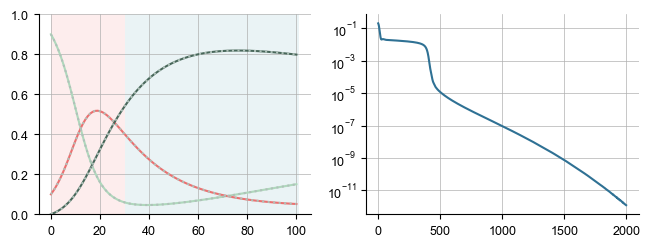

In [5]:
fig, axs = plt.subplots(ncols=2, figsize=(6, 2))
plot_preds_to_axs(key='params', ax=axs[0], NN=data['NN_params'], X_input=data['X_input'], y0=y0, dt=dt, t_span=t_span, Y_target=data['Y_target'], Y_input=data['Y_input'], L=L)
axs[1].plot(data['loss']['params'], c=colors['c_darkblue'])
axs[1].set_yscale('log')

### Hybrid (1)
This is the first level of hybridisation: two neural networks are coupled using a joint optimizer (see `hybrid_models.hybrid_1`):

In [6]:
for i in (pbar := tqdm.trange(10000)):
    epoch(
        key='hybrid_1',
        NN=data['NN_hybrid_1'],
        X_input=data['X_input'],
        Y_target=data['Y_target'][:L],
        dt=dt,
        y0=y0,
        t_span=(0, L*dt),
        Y_input=data['Y_input'],
        loss_array=data['loss']['hybrid_1'])

100%|██████████| 10000/10000 [00:22<00:00, 448.30it/s]


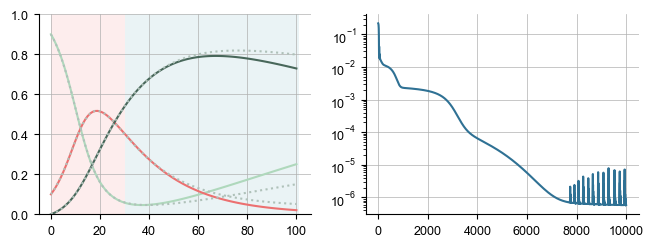

In [7]:
fig, axs = plt.subplots(ncols=2, figsize=(6, 2))
plot_preds_to_axs(key='hybrid_1', ax=axs[0], NN=data['NN_hybrid_1'], X_input=data['X_input'], y0=y0, dt=dt, Y_target=data['Y_target'], Y_input=data['Y_target'], t_span=t_span, L=L)
axs[1].plot(data['loss']['hybrid_1'], c=colors['c_darkblue'])
axs[1].set_yscale('log')

### Hybrid (2)
Since we are only learning time-dependent components, we can use a single neural network:

In [8]:
for i in (pbar := tqdm.trange(10000)):
    epoch(
        key='hybrid_2',
        NN=data['NN_hybrid_2'],
        Y_target=data['Y_target'][:L],
        dt=dt,
        t_span=(0, L*dt),
        y0=y0,
        Y_input=data['Y_input'],
        loss_array=data['loss']['hybrid_2'])

100%|██████████| 10000/10000 [00:14<00:00, 688.04it/s]


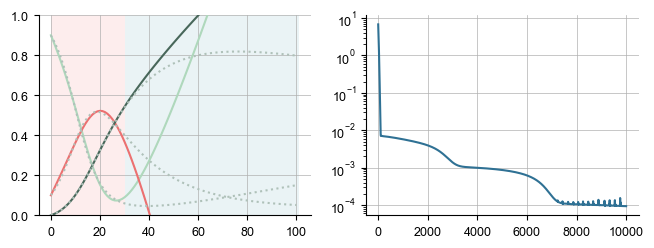

In [9]:
fig, axs = plt.subplots(ncols=2, figsize=(6, 2))
plot_preds_to_axs(key='hybrid_2', ax=axs[0], NN=data['NN_hybrid_2'], y0=y0, dt=dt, t_span=t_span, Y_target=data['Y_target'], Y_input=data['Y_target'], L=L)
axs[1].plot(data['loss']['hybrid_2'], c=colors['c_darkblue'])
axs[1].set_yscale('log')

### Black-box
Lastly, we consider a neural ODE:

In [10]:
for i in (pbar := tqdm.trange(10000)):
    epoch(
        key='bb',
        NN=data['NN_bb'],
        Y_target=data['Y_target'][:L],
        dt=dt,
        t_span=(0, L*dt),
        y0=y0,
        Y_input=data['Y_input'],
        loss_array=data['loss']['bb'])

100%|██████████| 10000/10000 [00:10<00:00, 986.58it/s]


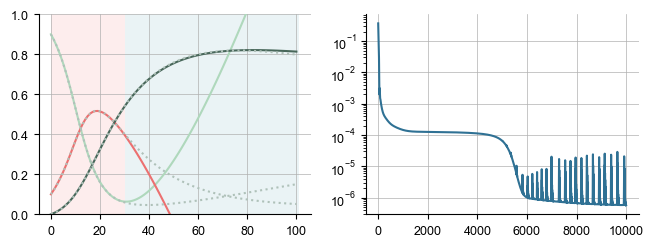

In [11]:
fig, axs = plt.subplots(ncols=2, figsize=(6, 2))
plot_preds_to_axs(key='bb', ax=axs[0], NN=data['NN_bb'], y0=y0, dt=dt, t_span=t_span, Y_target=data['Y_target'], Y_input=data['Y_target'], L=L)
axs[1].plot(data['loss']['bb'], c=colors['c_darkblue'])
axs[1].set_yscale('log')

## Experiments on a single dataset (recursive case)
In all the above experiments, we used observation data as input to the neural networks. Here, we repeat the experiments, using the recursively generated ODE solution as input to the neural networks where possible. Since the data we are using is noiseless, the results are broadly similar. Recursive training can be turned on/off by setting `recursive=True` in the relevant functions.

In [12]:
data['NN_hybrid_1_recursive'] = get_hybrid_1_NN(input_size=data['X_input'].shape[0])
data['NN_hybrid_2_recursive'] = get_hybrid_2_NN()
data['NN_bb_recursive'] = get_bb_NN()
data.update(dict(loss_recursive=dict(params=[], hybrid_1=[], hybrid_2=[], bb=[])))

## Hybrid (1)

In [13]:
for i in (pbar := tqdm.trange(10000)):
    epoch(
        key='hybrid_1',
        NN=data['NN_hybrid_1_recursive'],
        X_input=data['X_input'],
        Y_target=data['Y_target'][:L],
        dt=dt,
        y0=y0,
        t_span=(0, L*dt),
        recursive=True,
        Y_input=data['Y_input'],
        loss_array=data['loss_recursive']['hybrid_1'])

100%|██████████| 10000/10000 [00:44<00:00, 225.97it/s]


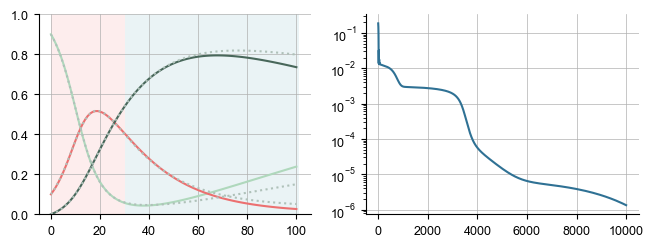

In [14]:
fig, axs = plt.subplots(ncols=2, figsize=(6, 2))
plot_preds_to_axs(key='hybrid_1', ax=axs[0], NN=data['NN_hybrid_1_recursive'], X_input=data['X_input'], y0=y0, dt=dt, Y_target=data['Y_target'], Y_input=data['Y_target'], t_span=t_span, L=L, recursive=True)
axs[1].plot(data['loss_recursive']['hybrid_1'], c=colors['c_darkblue'])
axs[1].set_yscale('log')

## Hybrid (2)

In [17]:
for i in (pbar := tqdm.trange(20000)):
    epoch(
        key='hybrid_2',
        NN=data['NN_hybrid_2_recursive'],
        Y_target=data['Y_target'][:L],
        dt=dt,
        t_span=(0, L*dt),
        y0=y0,
        Y_input=data['Y_input'],
        loss_array=data['loss_recursive']['hybrid_2'])

100%|██████████| 10000/10000 [00:14<00:00, 698.32it/s]


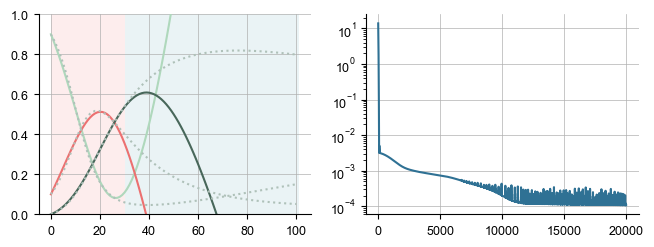

In [18]:
fig, axs = plt.subplots(ncols=2, figsize=(6, 2))
plot_preds_to_axs(key='hybrid_2', ax=axs[0], NN=data['NN_hybrid_2_recursive'], y0=y0, dt=dt, t_span=t_span, Y_target=data['Y_target'], Y_input=data['Y_target'], L=L, recursive=True)
axs[1].plot(data['loss_recursive']['hybrid_2'], c=colors['c_darkblue'])
axs[1].set_yscale('log')

## Black-box

In [19]:
data['NN_bb_recursive'] = get_bb_NN()
data['loss_recursive']['bb'] = []

In [20]:
for i in (pbar := tqdm.trange(10000)):
    epoch(
        key='bb',
        NN=data['NN_bb_recursive'],
        Y_target=data['Y_target'][:L],
        dt=dt,
        t_span=(0, L*dt),
        y0=y0,
        recursive=True,
        Y_input=data['Y_input'],
        loss_array=data['loss_recursive']['bb'])

100%|██████████| 10000/10000 [00:29<00:00, 342.32it/s]


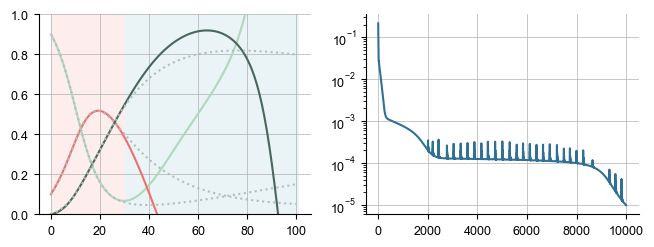

In [21]:
fig, axs = plt.subplots(ncols=2, figsize=(6, 2))
plot_preds_to_axs(key='bb', ax=axs[0], NN=data['NN_bb_recursive'], y0=y0, dt=dt, t_span=t_span, Y_target=data['Y_target'], Y_input=data['Y_target'], L=L, recursive=True)
axs[1].plot(data['loss_recursive']['bb'], c=colors['c_darkblue'])
axs[1].set_yscale('log')